In [1]:
# Install hypertools (dev-1.0 preview) -- run this first on Colab.
# On release this becomes: %pip install hypertools
import importlib.util
if importlib.util.find_spec('hypertools') is None:
    %pip install -q "hypertools[interactive] @ git+https://github.com/ContextLab/hypertools.git@dev-1.0"

# Visualizing Hugging Face text embeddings

Modern language models turn text into high-dimensional embedding vectors -- a perfect
match for HyperTools! In this tutorial we'll embed news headlines from a
[Hugging Face](https://huggingface.co) dataset using a small
[sentence-transformers](https://www.sbert.net) model, and then use HyperTools to
explore the embedding space.

This tutorial uses two extra libraries that are *not* installed with HyperTools.
You can install them by running:

```
%pip install sentence-transformers datasets
```


In [1]:
%matplotlib inline
import os
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
os.environ['HF_HUB_VERBOSITY'] = 'error'

import warnings
warnings.filterwarnings('ignore')

# env vars and warnings filters above must run before importing the
# libraries they configure, so these imports are intentionally not at
# the top of the cell.
import datasets  # noqa: E402
from datasets import load_dataset  # noqa: E402

import hypertools as hyp  # noqa: E402

datasets.disable_progress_bars()

## Embedding news headlines

We'll use a small sample (400 headlines) from the
[AG News](https://huggingface.co/datasets/fancyzhx/ag_news) dataset, which contains news
headlines from four categories: World, Sports, Business, and Sci/Tech.  To turn
each headline into a vector we'll use
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
a compact sentence-embedding model that maps each document onto a 384-dimensional
vector.

HyperTools does the embedding itself: every `hyp.plot` call below takes the raw headlines together with `vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None`, which hands the text straight to that sentence-transformers model (`semantic=None` skips the topic-model stage HyperTools applies to text by default). Encoding 400 headlines takes about a second, so re-encoding per call costs less than carrying an embedding matrix around.

In [2]:
dataset = load_dataset('fancyzhx/ag_news', split='train[:2000]')
dataset = dataset.shuffle(seed=42).select(range(400))  # a mixed 400-headline sample

label_names = dataset.features['label'].names
headlines = list(dataset['text'])   # a plain list of strings, not a datasets Column
categories = [label_names[i] for i in dataset['label']]
len(headlines)

400

## Plotting the embedding space

Passing the category labels via the `hue` argument colors each headline by its
news category, and `legend=True` labels those groups (it derives the group
names from `hue` itself, in order of first appearance).
HyperTools embeds the headlines and reduces the 384-dimensional embeddings to 3D (using incremental PCA
by default) before plotting.

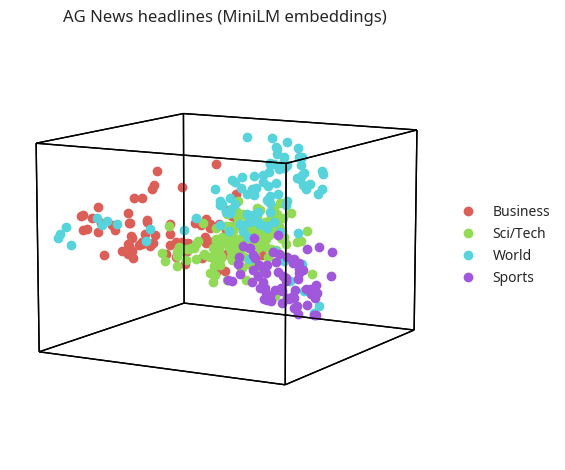

In [3]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               hue=categories, legend=True,
               title='AG News headlines (MiniLM embeddings)')

Even in three dimensions, headlines from the same category tend to occupy the
same part of the embedding space.

## Soft clustering with Gaussian mixture models

What if we didn't know the category labels? We can discover structure directly
from the embeddings.  Setting `cluster='GaussianMixture'` fits a mixture model
and colors each observation by its *blend* of cluster memberships -- points
that sit between clusters get intermediate colors, revealing the soft category
boundaries.

We pass `n_clusters=4` to match the four known AG News categories; for a mixture model HyperTools forwards that count as `n_components`. The mixture is fit to the 3-D reduced coordinates that get drawn, not to the raw 384-dimensional vectors, and each point's color reflects its cluster membership.

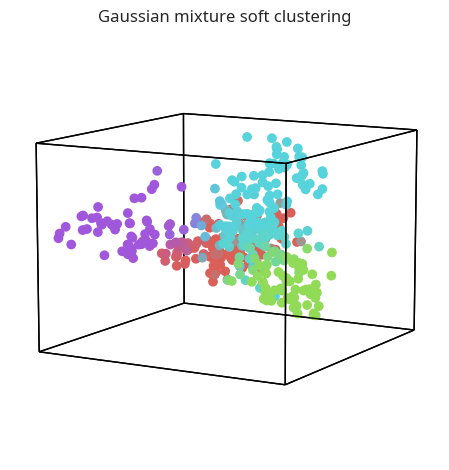

In [4]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               cluster='GaussianMixture', n_clusters=4,
               title='Gaussian mixture soft clustering')

## Nonlinear embeddings with UMAP

PCA is linear; nonlinear methods like [UMAP](https://umap-learn.readthedocs.io)
can often do a better job of untangling text embeddings.  Just pass
`reduce='UMAP'`:

`ndims=2` asks for a flat 2-D projection instead of the default 3. UMAP is stochastic and is left unseeded here, so the layout differs from run to run; pass `reduce={'model': 'UMAP', 'kwargs': {'random_state': 42}}` to fix it in place.

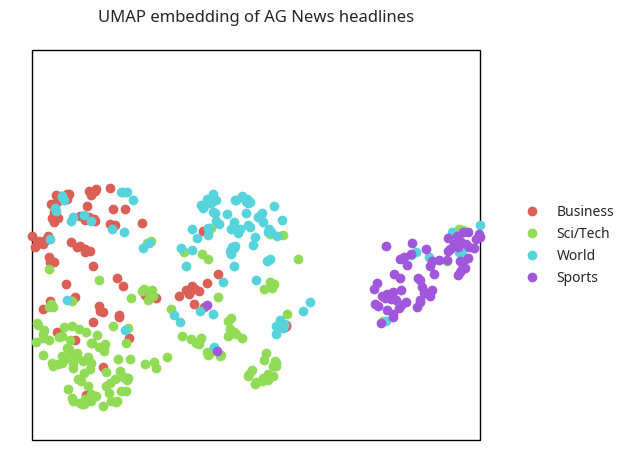

In [5]:
fig = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
               reduce='UMAP', ndims=2,
               hue=categories, legend=True,
               title='UMAP embedding of AG News headlines')

## Animated 3D visualization

Finally, HyperTools can animate the plot -- `animate='spin'` slowly rotates
the 3D scatter once around (over 20 seconds, at 15 frames per second) so we
can inspect it from every angle.  `save_path='hf_embeddings_spin.gif'` writes the GIF directly (MP4, GIF and
animated SVG are all supported; hypertools writes the GIF itself):

In [6]:
anim = hyp.plot(headlines, 'o', vectorizer='all-MiniLM-L6-v2', semantic=None, corpus=None,
                hue=categories, animate='spin',
                duration=20, rotations=1, frame_rate=15,
                save_path='hf_embeddings_spin.gif', show=False)

![Spinning 3D map of AG News headline embeddings](hf_embeddings_spin.gif)

*(The animation above is loaded from `hf_embeddings_spin.gif`, written by the cell above; if your environment does not render it inline, open the file directly.)*

## Next steps

Try swapping in a different Hugging Face dataset or embedding model, aligning
embeddings from *two* models with `hyp.align`, or exploring interactive 3D
plots with `backend='plotly'`.